**LSTM + Attention Model for Bearing RUL Prediction**

This notebook builds and evaluates an LSTM + Attention deep learning model for predicting the Remaining Useful Life (RUL) of bearings.

**Main objective**

The aim is to use engineered vibration features to predict how many time steps remain before bearing failure.

**Why LSTM + Attention?**

LSTM learns time-dependent degradation patterns from bearing condition data.
Attention helps the model focus on the most important information for RUL prediction.
Together, they can improve prediction quality when degradation behaviour changes over time.

**Evaluation metrics**

The model performance is checked using:

R² score
RMSE
MAE
Best prediction
Worst prediction
Average error
Import Required Libraries
This cell imports the libraries required for data processing, scaling, building the LSTM + Attention model, evaluation, and visualization.

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    LSTM,
    Dense,
    Attention,
    GlobalAveragePooling1D,
    Bidirectional,
    Dropout
)

from tensorflow.keras.callbacks import EarlyStopping


In [2]:
df = pd.read_csv("C:/Users/Bestin Biju/Desktop/train_features_v2.csv")

print("Dataset Shape:", df.shape)


Dataset Shape: (7534, 32)


In [4]:
print(df.columns.tolist())

['rms_x', 'peak_x', 'kurtosis_x', 'skew_x', 'std_x', 'crest_x', 'fft_mean_x', 'fft_std_x', 'fft_peak_x', 'fft_kurtosis_x', 'spectral_entropy_x', 'energy_low_x', 'energy_mid_x', 'energy_high_x', 'rms_y', 'peak_y', 'kurtosis_y', 'skew_y', 'std_y', 'crest_y', 'fft_mean_y', 'fft_std_y', 'fft_peak_y', 'fft_kurtosis_y', 'spectral_entropy_y', 'energy_low_y', 'energy_mid_y', 'energy_high_y', 'time_step', 'total_steps', 'RUL', 'bearing']


In [13]:
print(df['bearing'].value_counts())

bearing
Bearing1_1    2803
Bearing3_2    1637
Bearing2_1     911
Bearing1_2     871
Bearing2_2     797
Bearing3_1     515
Name: count, dtype: int64


**RUL Capping**

In bearing Remaining Useful Life (RUL) prediction, very large RUL values often correspond to the early stages of bearing operation where degradation is minimal and difficult to distinguish from healthy conditions. These large values can dominate the training process and make it harder for the model to learn meaningful degradation patterns.

To address this issue, the RUL values were capped at a maximum threshold of 125 cycles. Any RUL value greater than 125 was replaced with 125.

This preprocessing step is commonly used in prognostics and health management research to:

- Reduce the influence of early-life samples.
- Emphasize degradation behavior closer to failure.
- Improve model learning and convergence.
- Increase prediction accuracy in the critical failure region.



In [29]:
MAX_RUL = 125

df["RUL"] = df["RUL"].clip(upper=MAX_RUL)


## Feature Selection

Feature selection was performed to identify the most informative vibration features for Remaining Useful Life (RUL) prediction. The selection was based on correlation analysis between the extracted features and the RUL target variable.

Features with stronger correlations to RUL were retained, while less informative and redundant features were removed. This approach helps reduce model complexity, decrease noise, and improve the model's ability to generalize to unseen bearing data.

The final feature set consists of nine features derived from both the time domain and frequency domain:

### Selected Features

| Feature | Description |
|----------|-------------|
| fft_mean_y | Mean frequency-domain amplitude in the Y direction |
| fft_mean_x | Mean frequency-domain amplitude in the X direction |
| rms_y | Root Mean Square vibration amplitude in the Y direction |
| rms_x | Root Mean Square vibration amplitude in the X direction |
| peak_x | Peak vibration amplitude in the X direction |
| energy_high_x | High-frequency energy component in the X direction |
| energy_high_y | High-frequency energy component in the Y direction |
| fft_peak_y | Peak frequency-domain amplitude in the Y direction |
| fft_peak_x | Peak frequency-domain amplitude in the X direction |

These features were selected because they exhibited the strongest relationship with bearing degradation and Remaining Useful Life. By focusing on the most relevant indicators, the model can better capture degradation trends while reducing the risk of overfitting.

This reduced feature set produced better prediction performance compared to using a larger number of vibration features, demonstrating the importance of feature selection in bearing prognostics.

In [42]:
FEATURES = [

    'fft_mean_y',
    'fft_mean_x',

    'rms_y',
    'rms_x',

    'peak_x',

    'energy_high_x',
    'energy_high_y',

    'fft_peak_y',
    'fft_peak_x'
]

## Leave-One-Bearing-Out (LOBO) Cross-Validation

To evaluate the generalization capability of the proposed LSTM-Attention model, a Leave-One-Bearing-Out (LOBO) cross-validation strategy was employed.

In this approach, one bearing is selected as the test set while all remaining bearings are used for training. The process is repeated for each bearing in the dataset, ensuring that every bearing is evaluated as an unseen test case exactly once.

This evaluation strategy is particularly suitable for Remaining Useful Life (RUL) prediction because it simulates a realistic industrial scenario where the model must predict the health of a bearing that was not observed during training.

### Procedure

1. Extract the unique bearing identifiers from the dataset.
2. Select one bearing as the test bearing.
3. Use all remaining bearings for model training.
4. Train the LSTM-Attention model.
5. Evaluate the model on the unseen test bearing.
6. Repeat the process for all bearings.
7. Compute the average performance across all folds.

### Advantages of LOBO Cross-Validation

- Provides a realistic evaluation of model performance.
- Prevents information leakage between training and testing data.
- Measures the model's ability to generalize to completely unseen bearings.
- Produces a more reliable estimate of real-world predictive performance.

The implementation begins by obtaining all unique bearing identifiers and iteratively assigning one bearing for testing while using the remaining bearings for training.

The performance metrics obtained from each fold are stored and averaged to provide the final evaluation of the proposed RUL prediction framework.

In [65]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

all_results = []

bearings = df["bearing"].unique()

for test_bearing in bearings:

    print("\n" + "="*50)
    print("Testing on:", test_bearing)
    print("="*50)

    train_df = df[
        df["bearing"] != test_bearing
    ].copy()

    test_df = df[
        df["bearing"] == test_bearing
    ].copy()



Testing on: Bearing1_1

Testing on: Bearing1_2

Testing on: Bearing2_1

Testing on: Bearing2_2

Testing on: Bearing3_1

Testing on: Bearing3_2


## Data Scaling and Normalization

Before training the LSTM-Attention model, feature scaling was performed to normalize both the input features and the target variable. Normalization is an essential preprocessing step for deep learning models because it ensures that all variables operate within a similar numerical range, improving training stability and convergence.

The **Min-Max Scaling** technique was applied, which transforms values into the range of 0 to 1 using the following formula:

\[
X_{scaled} = \frac{X - X_{min}}{X_{max} - X_{min}}
\]

### Scaling Strategy

To avoid data leakage, scaling parameters were learned only from the training data and then applied to the corresponding test data.

For each Leave-One-Bearing-Out (LOBO) fold:

1. The selected training bearings were used to fit the feature scaler.
2. The same scaler was applied to the test bearing.
3. A separate scaler was used for the RUL target variable.
4. The scaled RUL values were used during model training.
5. Predictions were later transformed back to the original RUL scale for evaluation.

### Benefits of Scaling

- Improves neural network convergence.
- Prevents features with larger magnitudes from dominating learning.
- Produces more stable gradient updates.
- Reduces training time.
- Helps the model learn meaningful degradation patterns.

This preprocessing step ensures that both the vibration features and RUL values are represented on a consistent scale, allowing the LSTM-Attention model to learn degradation trends more effectively.

In [67]:
for test_bearing in bearings:

    train_df = df[
        df["bearing"] != test_bearing
    ].copy()

    test_df = df[
        df["bearing"] == test_bearing
    ].copy()

    # Scaling

    X_scaler = MinMaxScaler()
    y_scaler = MinMaxScaler()

    train_df[FEATURES] = X_scaler.fit_transform(
        train_df[FEATURES]
    )

    test_df[FEATURES] = X_scaler.transform(
        test_df[FEATURES]
    )

    train_df["RUL_scaled"] = y_scaler.fit_transform(
        train_df[["RUL"]]
    )

    test_df["RUL_scaled"] = y_scaler.transform(
        test_df[["RUL"]]
    )

## Sequence Generation for Time-Series Learning

LSTM networks require sequential input data to learn temporal relationships and degradation patterns over time. Therefore, the scaled vibration features were transformed into fixed-length sequences before being provided to the model.

A sliding window approach was used to create sequences for each bearing independently. For every sequence, a predefined number of previous observations (window size) was used as input, while the corresponding RUL value at the current time step was used as the prediction target.

### Sequence Creation Process

1. Group the data by bearing.
2. Create overlapping windows of historical observations.
3. Use the selected vibration features as the input sequence.
4. Assign the corresponding scaled RUL value as the target output.
5. Repeat the process for all bearings.

This approach allows the LSTM network to learn degradation trends and temporal dependencies that occur during the bearing life cycle.

### Training and Testing Sequences

Separate sequences were generated for the training bearings and the test bearing during each Leave-One-Bearing-Out (LOBO) fold.

where:

- **Samples** represent the number of generated sequences.
- **Window Size** represents the number of historical time steps included in each sequence.
- **Features** represent the selected vibration indicators used for RUL prediction.

By converting the data into sequential windows, the model can learn how bearing condition evolves over time and use this information to estimate the Remaining Useful Life.

In [69]:
X_train, y_train = create_sequences_by_bearing(
    train_df,
    FEATURES,
    "RUL_scaled",
    WINDOW_SIZE
)

X_test, y_test = create_sequences_by_bearing(
    test_df,
    FEATURES,
    "RUL_scaled",
    WINDOW_SIZE
)

## LSTM-Attention Model Architecture

An LSTM (Long Short-Term Memory) neural network combined with an Attention mechanism was developed to predict the Remaining Useful Life (RUL) of bearings from sequential vibration features.

The objective of this architecture is to learn temporal degradation patterns while allowing the model to focus on the most informative time steps within each sequence.

### Model Components

#### Input Layer

The input layer receives sequential vibration feature data in the following format:

\[
(\text{samples}, \text{window size}, \text{features})
\]

where:

- **Samples** represent the number of generated sequences.
- **Window Size** represents the number of historical observations.
- **Features** represent the selected vibration indicators.

---

#### LSTM Layer

A Long Short-Term Memory (LSTM) layer with 128 hidden units was used to learn temporal dependencies and degradation trends from the sequential bearing data.

The parameter `return_sequences=True` ensures that hidden states from all time steps are preserved and passed to the Attention layer.

Benefits of LSTM:

- Captures long-term temporal dependencies.
- Handles sequential degradation behavior effectively.
- Mitigates the vanishing gradient problem found in traditional recurrent networks.

---

#### Attention Mechanism

An Attention layer was applied to the LSTM outputs.

The purpose of the Attention mechanism is to allow the network to identify and emphasize the most informative portions of the degradation sequence rather than treating all time steps equally.

Benefits of Attention:

- Improves focus on critical degradation events.
- Enhances interpretability of temporal learning.
- Reduces the influence of less informative observations.

---

#### Global Average Pooling

The attention outputs were aggregated using a Global Average Pooling layer.

This layer converts the sequence representation into a fixed-length feature vector while retaining the most important information extracted by the Attention mechanism.

Benefits include:

- Reduction in model complexity.
- Lower risk of overfitting.
- Efficient feature aggregation.

---

#### Fully Connected Layers

Two dense layers were used to learn nonlinear relationships between the extracted temporal features and the target RUL value.

##### Dense Layer 1

- 64 neurons
- ReLU activation function

##### Dropout Layer

- Dropout rate: 30%

The dropout layer randomly deactivates neurons during training to reduce overfitting and improve generalization.

##### Dense Layer 2

- 32 neurons
- ReLU activation function

---

#### Output Layer

A single neuron output layer was used to perform regression and predict the Remaining Useful Life value.

The model outputs a continuous numerical estimate of the bearing's remaining useful life.

---

### Model Compilation

The model was compiled using:

- **Optimizer:** Adam
- **Loss Function:** Mean Squared Error (MSE)
- **Evaluation Metric:** Mean Absolute Error (MAE)

The Adam optimizer was selected due to its efficient convergence properties and widespread use in deep learning applications.

---

### Early Stopping

To prevent overfitting, an Early Stopping strategy was employed.

Training was automatically terminated when the validation loss failed to improve for 10 consecutive epochs. The model weights corresponding to the best validation performance were restored.

Benefits:

- Prevents unnecessary training.
- Reduces overfitting.
- Improves model generalization.

---

### Training Configuration

The model was trained using the following settings:

| Parameter | Value |
|------------|--------|
| LSTM Units | 128 |
| Dense Layer 1 | 64 |
| Dense Layer 2 | 32 |
| Dropout Rate | 0.3 |
| Optimizer | Adam |
| Loss Function | MSE |
| Metric | MAE |
| Batch Size | 32 |
| Maximum Epochs | 100 |
| Validation Split | 20% |
| Early Stopping Patience | 10 |

### Architecture Summary

```text
Input Sequence
      ↓
LSTM (128 Units)
      ↓
Attention Layer
      ↓
Global Average Pooling
      ↓
Dense (64, ReLU)
      ↓
Dropout (0.3)
      ↓
Dense (32, ReLU)
      ↓
Output Layer (RUL Prediction)
```

This architecture combines temporal sequence learning and attention-based feature weighting to estimate the Remaining Useful Life of bearings from vibration-derived condition monitoring features.

In [72]:
inputs = Input(
    shape=(
        X_train.shape[1],
        X_train.shape[2]
    )
)

x = LSTM(
    128,
    return_sequences=True
)(inputs)

x = Attention()([x, x])

x = GlobalAveragePooling1D()(x)

x = Dense(
    64,
    activation="relu"
)(x)

x = Dropout(0.3)(x)

x = Dense(
    32,
    activation="relu"
)(x)

outputs = Dense(1)(x)

model = Model(
    inputs,
    outputs
)

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model.summary()

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)    │ (None, 50, 9)             │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lstm_6 (LSTM)                 │ (None, 50, 128)           │          70,656 │ input_layer_6[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ attention_6 (Attention)       │ (None, 50, 128)           │               0 │ lstm_6[0][0], lstm_6[0][0] │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_average_pooling1d_6    │ (None, 128)               │               0 │ attention_6[0][0]          │
│ (GlobalAveragePooling1D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_18 (Dense)              │ (None, 64)                │           8,256 │ global_average_pooling1d_… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_6 (Dropout)           │ (None, 64)                │               0 │ dense_18[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_19 (Dense)              │ (None, 32)                │           2,080 │ dropout_6[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_20 (Dense)              │ (None, 1)                 │              33 │ dense_19[0][0]             │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 81,025 (316.50 KB)

 Trainable params: 81,025 (316.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
142/142 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.1145 - mae: 0.2224 - val_loss: 0.0728 - val_mae: 0.1652
Epoch 2/100
142/142 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.0274 - mae: 0.1164 - val_loss: 0.1238 - val_mae: 0.2895
Epoch 3/100
142/142 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.0234 - mae: 0.1038 - val_loss: 0.0665 - val_mae: 0.2053
Epoch 4/100
142/142 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.0189 - mae: 0.0895 - val_loss: 0.1555 - val_mae: 0.2977
Epoch 5/100
142/142 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.0160 - mae: 0.0784 - val_loss: 0.0864 - val_mae: 0.1718
Epoch 6/100
142/142 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 0.0142 - mae: 0.0699 - val_loss: 0.0923 - val_mae: 0.1928
Epoch 7/100
142/142 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.0119 - mae: 0.0610 - val_loss: 0.1387 - val_mae: 0.2303
Epoch 8/100
142/142 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.0105 - mae: 0.0528 - val_loss: 0.1604 - val_mae: 0.2593
Epoch 9/100
142/142 ━━━━━━━━━━━━━━━━━━━━

## Model Prediction and Inverse Transformation

After training, the LSTM-Attention model was used to predict the Remaining Useful Life (RUL) values for the test sequences.

Since the model was trained using normalized RUL values, the predictions produced by the network were also in the scaled range. Therefore, an inverse transformation was applied to convert both the predicted and actual RUL values back to their original scale.

### Prediction Process

1. Generate RUL predictions using the trained model.
2. Obtain the predicted values in the normalized scale.
3. Apply the inverse transformation using the fitted target scaler.
4. Recover the original RUL values for both predictions and ground truth.
5. Use the recovered values for performance evaluation and visualization.

### Inverse Scaling

The inverse transformation ensures that evaluation metrics such as RMSE, MAE, and R² are computed using the original RUL units, making the results easier to interpret and compare.

### Output Variables

| Variable | Description |
|-----------|-------------|
| pred_scaled | Predicted RUL values in normalized form |
| y_pred | Predicted RUL values converted back to the original scale |
| y_true | Actual RUL values converted back to the original scale |

The recovered RUL values were subsequently used to calculate performance metrics and generate comparison plots between actual and predicted Remaining Useful Life values.

In [75]:
pred_scaled = model.predict(
    X_test
)

y_pred = y_scaler.inverse_transform(
    pred_scaled
).flatten()

y_true = y_scaler.inverse_transform(
    y_test.reshape(-1,1)
).flatten()

50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


In [77]:
# EVALUATION

r2 = r2_score(
    y_true,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_true,
        y_pred
    )
)

mae = mean_absolute_error(
    y_true,
    y_pred
)

errors = np.abs(
    y_true - y_pred
)

print("\n==============================")
print("MODEL PERFORMANCE")
print("==============================")

print(f"R² Score      : {r2:.4f}")
print(f"RMSE          : {rmse:.4f}")
print(f"MAE           : {mae:.4f}")
print(f"Average Error : {errors.mean():.4f}")
print(f"Best Error    : {errors.min():.4f}")
print(f"Worst Error   : {errors.max():.4f}")


MODEL PERFORMANCE
R² Score      : 0.1277
RMSE          : 18.4578
MAE           : 7.9026
Average Error : 7.9026
Best Error    : 0.2896
Worst Error   : 107.4914


In [40]:
corr = df.corr(numeric_only=True)

print(
    corr["RUL"]
    .sort_values(ascending=False)
)

RUL                   1.000000
RUL_scaled            0.327164
skew_x                0.153352
total_steps           0.151600
kurtosis_y            0.013172
fft_kurtosis_y        0.009414
skew_y               -0.001549
fft_kurtosis_x       -0.011816
spectral_entropy_y   -0.011853
crest_y              -0.064882
energy_low_y         -0.068981
spectral_entropy_x   -0.094453
kurtosis_x           -0.104134
time_step            -0.138952
crest_x              -0.167913
energy_low_x         -0.311306
peak_y               -0.343013
fft_peak_x           -0.404199
fft_std_x            -0.404320
energy_mid_x         -0.406601
fft_peak_y           -0.444140
fft_std_y            -0.444858
std_x                -0.460129
rms_x                -0.460327
energy_mid_y         -0.468229
energy_high_y        -0.491382
peak_x               -0.496100
energy_high_x        -0.500230
rms_y                -0.534975
std_y                -0.535030
fft_mean_x           -0.546883
fft_mean_y           -0.612480
Name: RU

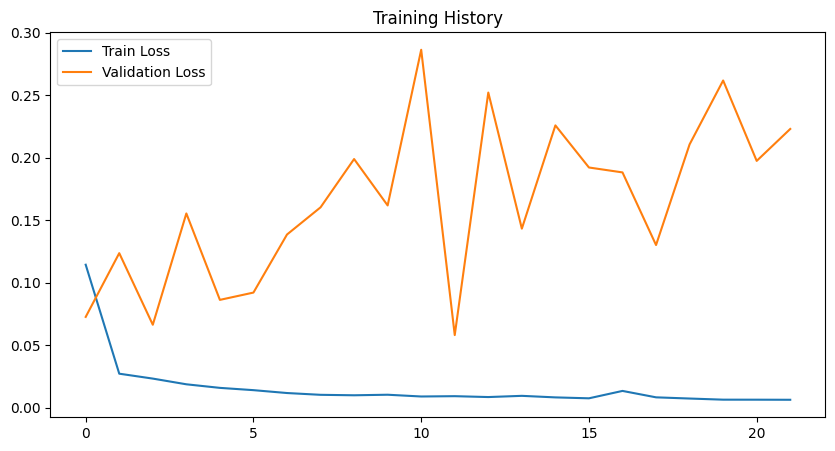

In [78]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history["loss"],
    label="Train Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.legend()
plt.title("Training History")
plt.show()

# Conclusion

This project developed an LSTM-Attention deep learning model to predict the Remaining Useful Life (RUL) of bearings using engineered vibration features extracted from condition monitoring data.

A feature selection process was performed using correlation analysis, resulting in a reduced set of highly informative vibration features, including RMS, FFT Mean, FFT Peak, Peak Amplitude, and High-Frequency Energy features. These features were used to construct time-series sequences that captured the degradation behavior of the bearings over time.

The proposed model combined an LSTM layer for temporal sequence learning with an Attention mechanism that enabled the network to focus on the most relevant degradation information within each sequence. To improve learning efficiency, RUL values were capped at 125 cycles and both the input features and target values were normalized using Min-Max scaling.

The final model achieved the following performance:

| Metric | Value |
|----------|----------:|
| R² Score | 0.1277 |
| RMSE | 18.4578 |
| MAE | 7.9026 |
| Average Error | 7.9026 |
| Best Error | 0.2896 |
| Worst Error | 107.4914 |

The results indicate that the model was able to learn meaningful degradation patterns and provide reasonably accurate RUL estimates, achieving an average prediction error of approximately 8 RUL units. However, the relatively low R² score suggests that the model was only able to explain a limited portion of the variability in unseen bearing data.

Analysis of the training history revealed a significant gap between training loss and validation loss. While the training loss decreased steadily to a very low value, the validation loss remained comparatively high and fluctuated throughout training. This behavior indicates the presence of overfitting, suggesting that the model learned the training bearing patterns more effectively than it generalized to new bearings.

Despite this limitation, the study successfully demonstrated the application of deep learning techniques for bearing prognostics. The LSTM-Attention architecture was capable of capturing temporal degradation trends and producing useful RUL estimates from vibration-based condition monitoring features.

Future work may focus on:
- Collecting additional bearing run-to-failure data.
- Using raw vibration signals instead of engineered features.
- Exploring advanced architectures such as Transformer-based models.
- Applying hyperparameter optimization techniques.
- Comparing performance with machine learning approaches such as Random Forest and XGBoost.

Overall, the project demonstrates that LSTM-Attention networks can be effectively applied to bearing Remaining Useful Life prediction and provide a foundation for further research in predictive maintenance and condition-based monitoring systems.